In [7]:
import torch
import os
from models.unet_resnet34 import get_model_unet_resnet34
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.color import rgb2lab, lab2rgb

def predecir_mi_foto(image_path, model, device):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((160, 160)) 
    img_np = np.array(img)
    img_lab = rgb2lab(img_np)
    L = img_lab[:, :, 0]
    L_norm = L / 100.0
    ab_real = img_lab[:, :, 1:] 
    L_tensor = torch.from_numpy(L_norm).unsqueeze(0).unsqueeze(0).float().to(device)
    model.eval()
    with torch.no_grad():
        pred_ab = model(L_tensor)
    pred_ab = pred_ab.cpu().squeeze().permute(1, 2, 0).numpy()
    pred_ab = pred_ab * 128
    resultado_lab = np.zeros((160, 160, 3))
    resultado_lab[:, :, 0] = L 
    resultado_lab[:, :, 1:] = pred_ab
    img_resultado_rgb = lab2rgb(resultado_lab)

    plt.figure(figsize=(12, 5))
    
    # A. Input (Blanco y Negro)
    plt.subplot(1, 3, 1)
    plt.imshow(L, cmap='gray')
    plt.title("Input (Escala de Grises)")
    plt.axis('off')
    
    # B. Predicción del Modelo
    plt.subplot(1, 3, 2)
    plt.imshow(img_resultado_rgb)
    plt.title("Colorización del Modelo")
    plt.axis('off')
    
    # C. Realidad (Ground Truth) - Ya que tenemos la foto color original
    plt.subplot(1, 3, 3)
    plt.imshow(img_np)
    plt.title("Realidad (Original)")
    plt.axis('off')
    
    plt.show()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



## Modelo Histograma

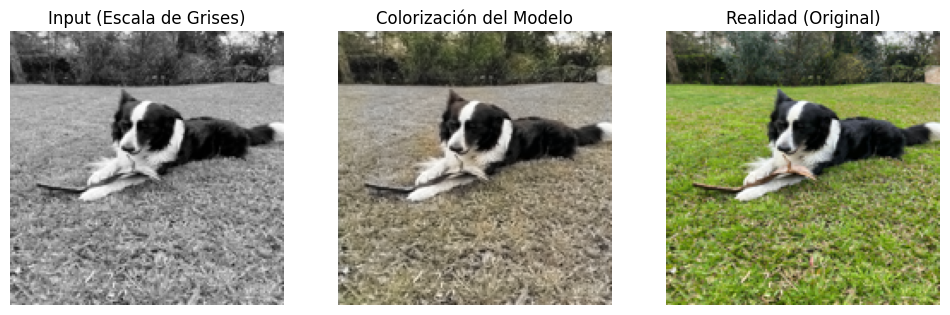

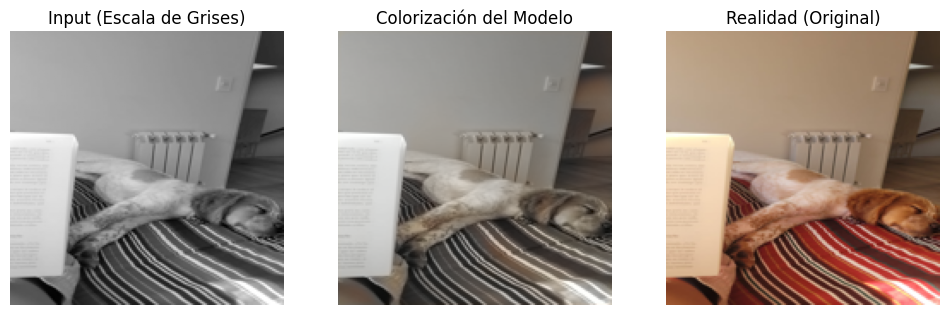

/var/folders/_9/j69067k14kd_cxht28b01f140000gn/T/ipykernel_89057/3428395519.py:26: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 54 negative Z values that have been clipped to zero
  img_resultado_rgb = lab2rgb(resultado_lab)


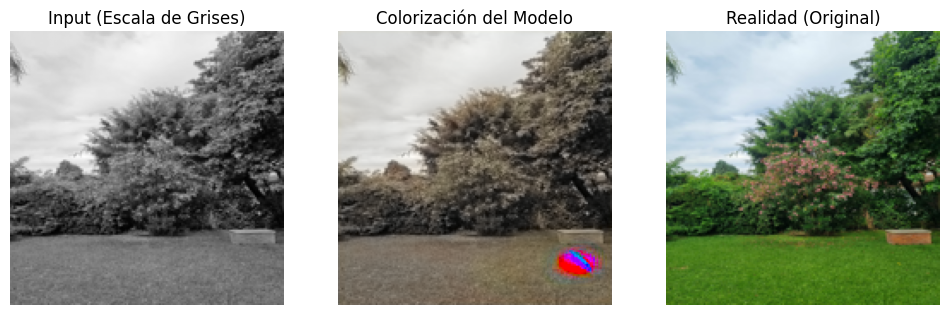

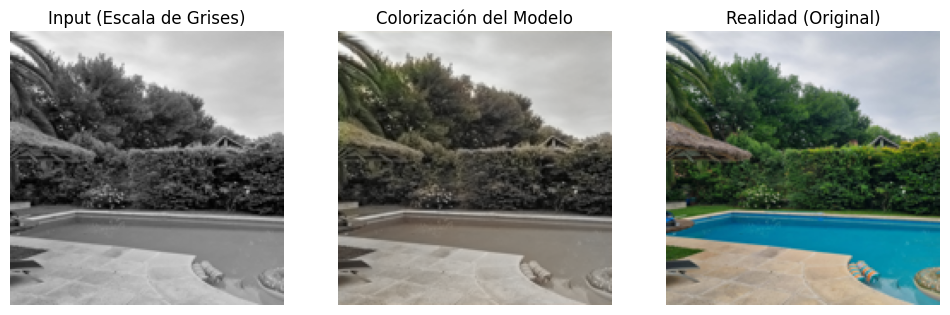

In [8]:
model_hist = get_model_unet_resnet34(pre_entrenado=True) 
model_hist.load_state_dict(torch.load("pesos_entrenados/unet_resnet34_histogram.pt", map_location=device))
model_hist.to(device)

fotos_inputs = "Inputs_propios" 
for img in os.listdir(fotos_inputs):
    img_path = os.path.join(fotos_inputs, img)
    predecir_mi_foto(img_path, model_hist, device)

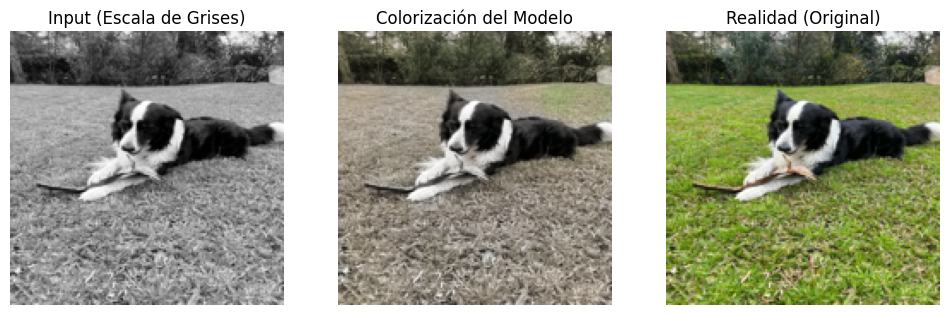

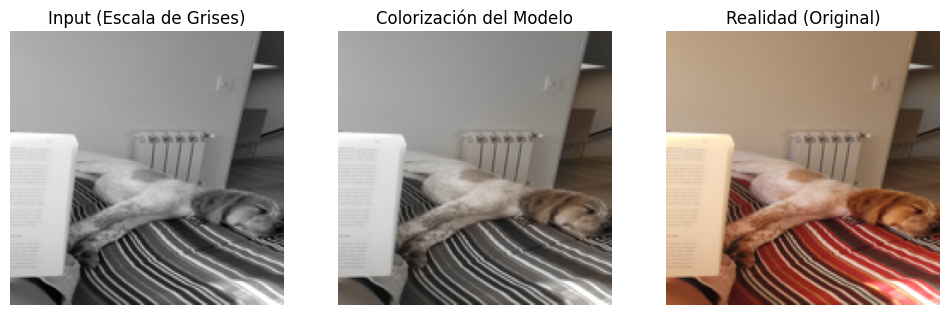

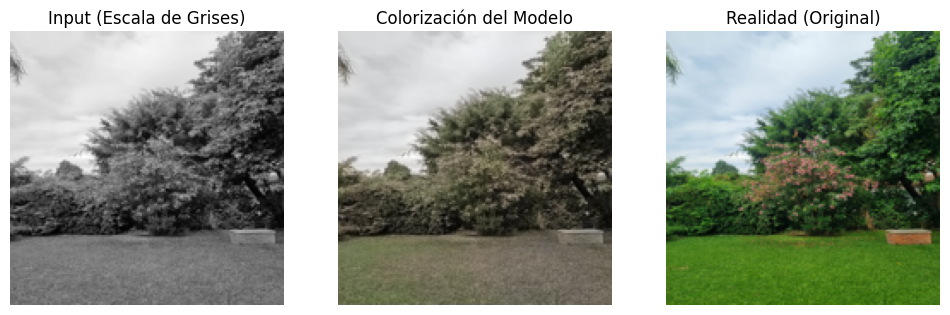

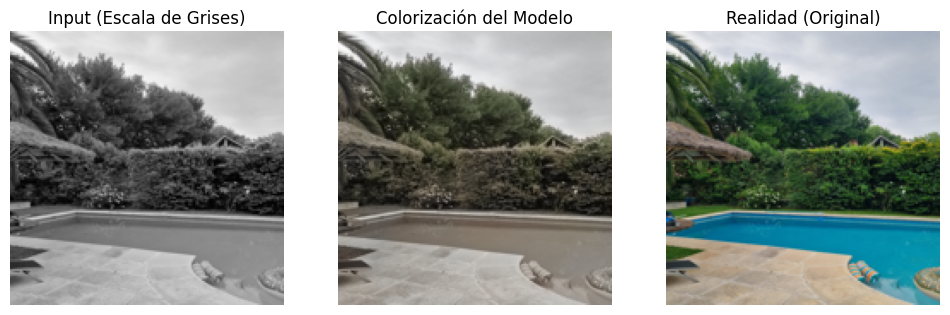

In [9]:
model_fr = get_model_unet_resnet34(pre_entrenado=True) 
model_fr.load_state_dict(torch.load("pesos_entrenados/unet_resnet34_frozen_l1.pt", map_location=device))
model_fr.to(device)

for img in os.listdir(fotos_inputs):
    img_path = os.path.join(fotos_inputs, img)
    predecir_mi_foto(img_path, model_fr, device)

In [ ]:
from models.unet import UNetColor
model_unet = UNetColor()
model_unet.load_state_dict(torch.load("pesos_entrenados/unetColor.pt", map_location=device))
model_unet.to(device)

for img in os.listdir(fotos_inputs):
    img_path = os.path.join(fotos_inputs, img)
    predecir_mi_foto(img_path, model_unet, device)